In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from scipy.stats import f as f_dist
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import time

In [2]:
# --- Mackey-Glass Generator ---
def mackey_glass(t_max, tau=17, delta_t=1, beta=0.2, gamma=0.1, n=10, x0=1.2):
    t_len = int(t_max / delta_t)
    x = np.zeros(t_len)
    x[0] = x0
    for t in range(1, t_len):
        if t - tau >= 0:
            x[t] = x[t - 1] + delta_t * (
                beta * x[t - tau] / (1 + x[t - tau] ** n) - gamma * x[t - 1]
            )
        else:
            x[t] = x[t - 1] - delta_t * gamma * x[t - 1]
    return x

# --- Parameters ---
t_max = 200
delta_t = 1
test_ic = 1.2
train_ics_all = np.concatenate((np.linspace(0, 1.19, 20), np.linspace(1.21, 3, 20)))
train_ics_train, train_ics_val = train_test_split(train_ics_all, test_size=0.1, random_state=42)
timesteps = np.arange(0, t_max, delta_t)

# --- Feature Generator ---
def generate_data(ics, t_max):
    X_list, y_list = [], []
    for ic in ics:
        x = mackey_glass(t_max=t_max, x0=ic)
        norm_t = timesteps / t_max
        features = np.stack([np.full_like(norm_t, ic), norm_t], axis=1)
        X_list.append(features)
        y_list.append(x)
    return np.vstack(X_list), np.concatenate(y_list), len(ics)

# --- Generate all sets ---
X_train, y_train, N_train = generate_data(train_ics_train, t_max)
X_val, y_val, N_val = generate_data(train_ics_val, t_max)
X_test, y_test, _ = generate_data([test_ic], t_max)

# --- Normalize ---
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# --- Reshape into (ICs*Timesteps, Features) ---
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

# --- Dataloaders ---
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64)

In [3]:
# --- Feed Forward Network ---
class FeedForwardNN(nn.Module):
    def __init__(self, input_size=2, hidden_size=128):
        super(FeedForwardNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)


In [4]:
model = FeedForwardNN()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# --- Train with validation tracking ---
train_losses = []
val_losses = []
start_time = time.time()
epochs = 200

for epoch in range(epochs):
    model.train()
    total_train_loss = 0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb.squeeze())
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    model.eval()
    total_val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            pred = model(xb)
            val_loss = criterion(pred, yb.squeeze())
            total_val_loss += val_loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = total_val_loss / len(val_loader)
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")


Epoch 0: Train Loss = 0.1547, Val Loss = 0.0653
Epoch 10: Train Loss = 0.0483, Val Loss = 0.0400
Epoch 20: Train Loss = 0.0249, Val Loss = 0.0196
Epoch 30: Train Loss = 0.0157, Val Loss = 0.0120
Epoch 40: Train Loss = 0.0121, Val Loss = 0.0094
Epoch 50: Train Loss = 0.0115, Val Loss = 0.0093
Epoch 60: Train Loss = 0.0092, Val Loss = 0.0081
Epoch 70: Train Loss = 0.0086, Val Loss = 0.0100
Epoch 80: Train Loss = 0.0074, Val Loss = 0.0081
Epoch 90: Train Loss = 0.0066, Val Loss = 0.0076
Epoch 100: Train Loss = 0.0063, Val Loss = 0.0063
Epoch 110: Train Loss = 0.0062, Val Loss = 0.0082
Epoch 120: Train Loss = 0.0057, Val Loss = 0.0066
Epoch 130: Train Loss = 0.0054, Val Loss = 0.0068
Epoch 140: Train Loss = 0.0054, Val Loss = 0.0062
Epoch 150: Train Loss = 0.0047, Val Loss = 0.0069
Epoch 160: Train Loss = 0.0045, Val Loss = 0.0057
Epoch 170: Train Loss = 0.0046, Val Loss = 0.0062
Epoch 180: Train Loss = 0.0042, Val Loss = 0.0072
Epoch 190: Train Loss = 0.0040, Val Loss = 0.0060


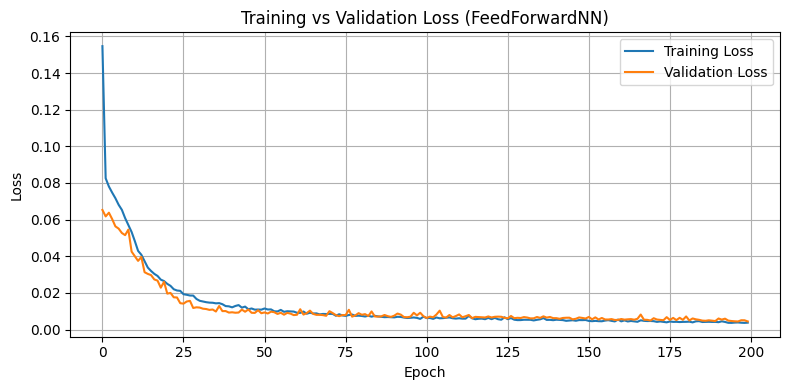


Test RMSE (IC=1.2): 0.0516
Test R² (IC=1.2):   0.9624
F-statistic: 2524.4941
P-value:     1.1102e-16
Total Runtime: 176.42 seconds


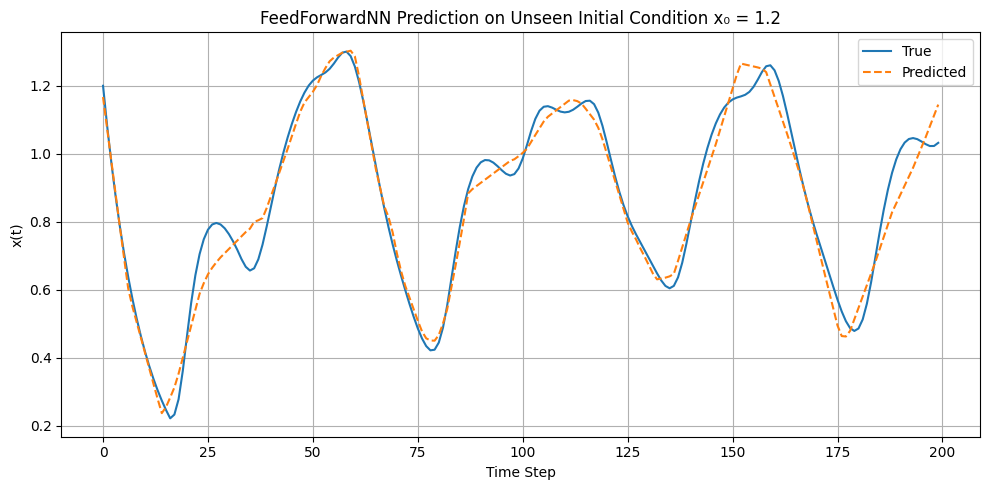

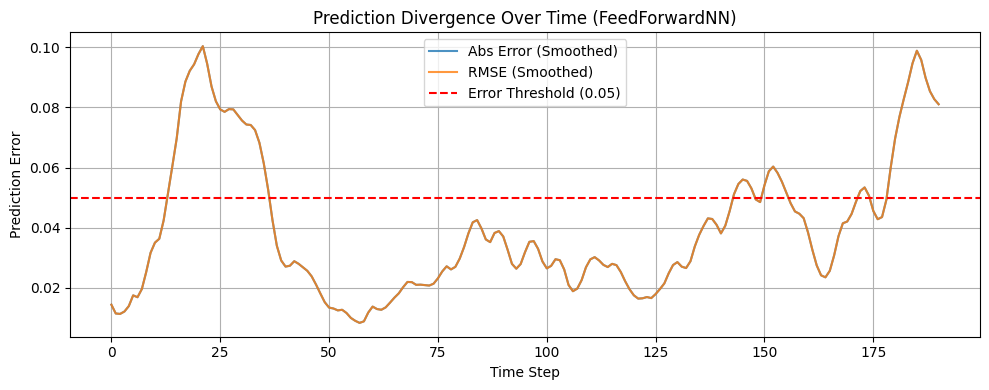

Prediction horizon at threshold 0.05: 23 steps
Total runtime: 178.13 seconds


In [6]:
end_time = time.time()

# --- Plot Training vs Validation Loss ---
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (FeedForwardNN)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Final Test ---
model.eval()
with torch.no_grad():
    pred_test = model(X_test_tensor).numpy()

rmse = np.sqrt(mean_squared_error(y_test, pred_test))
r2 = r2_score(y_test, pred_test)
print(f"\nTest RMSE (IC={test_ic}): {rmse:.4f}")
print(f"Test R² (IC={test_ic}):   {r2:.4f}")

# --- F-statistic and p-value ---
n = len(y_test)
k = X_test.shape[1]  # number of predictors = 2
F_stat = (r2 / k) / ((1 - r2) / (n - k - 1))
p_value = 1 - f_dist.cdf(F_stat, k, n - k - 1)

print(f"F-statistic: {F_stat:.4f}")
print(f"P-value:     {p_value:.4e}")
print(f"Total Runtime: {end_time - start_time:.2f} seconds")

# --- Plot Test Prediction ---
plt.figure(figsize=(10, 5))
plt.plot(y_test, label='True')
plt.plot(pred_test, label='Predicted', linestyle='--')
plt.title(f"FeedForwardNN Prediction on Unseen Initial Condition x₀ = {test_ic}")
plt.xlabel("Time Step")
plt.ylabel("x(t)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# --- Prediction Divergence / Horizon ---
errors = np.abs(pred_test - y_test)            # abs error
rmse_window = np.sqrt((pred_test - y_test)**2) # RMSE error

def moving_avg(x, w=10):
    return np.convolve(x, np.ones(w)/w, mode='valid')

window_size = 10
smoothed_error = moving_avg(errors, w=window_size)
smoothed_rmse = moving_avg(rmse_window, w=window_size)

plt.figure(figsize=(10, 4))
plt.plot(smoothed_error, label="Abs Error (Smoothed)", alpha=0.8)
plt.plot(smoothed_rmse, label="RMSE (Smoothed)", alpha=0.8)
plt.axhline(y=0.05, color='r', linestyle='--', label='Error Threshold (0.05)')
plt.title("Prediction Divergence Over Time (FeedForwardNN)")
plt.xlabel("Time Step")
plt.ylabel("Prediction Error")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

threshold = 0.05
divergence_time = np.argmax(smoothed_error > threshold) + window_size
print(f"Prediction horizon at threshold {threshold}: {divergence_time} steps")
print(f"Total runtime: {time.time() - start_time:.2f} seconds")